In [1]:
# [setup]
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ACCOUNTING_DATE = pd.Timestamp('2026-12-15')
PLOT_START = pd.Timestamp('2025-10-01')
PLOT_END = pd.Timestamp('2027-01-01')

NO_IRAN_DIR = 'data-official/comparisons/no-iran'
APRIL_DIR = 'data-official/comparisons/april'

FORECAST_FILES = {
    'april 02-27 (baseline)':               f'{APRIL_DIR}/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    'plus-iran 02-27':                      f'{NO_IRAN_DIR}/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.plus_iran.parquet',
    'no-iran 02-27':                        f'{NO_IRAN_DIR}/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    'no-iran 04-01 (desktop recent13)':     f'{NO_IRAN_DIR}/2026-04-01_desktop_recent13/mozaic_daily_forecast.2026-04-01.ld-D.parquet',
    'plus-iran 04-01 (desktop recent13)':   f'{NO_IRAN_DIR}/2026-04-01_desktop_recent13/mozaic_daily_forecast.2026-04-01.ld-D.plus_iran.parquet',
}

DATASET_STYLES = {
    'april 02-27 (baseline)':               {'color': 'black',   'linestyle': '-',  'linewidth': 2.2},
    'plus-iran 02-27':                      {'color': '#1565C0', 'linestyle': '-',  'linewidth': 2.0},
    'no-iran 02-27':                        {'color': '#E65100', 'linestyle': '-',  'linewidth': 2.0},
    'no-iran 04-01 (desktop recent13)':     {'color': '#C62828', 'linestyle': '--', 'linewidth': 1.6},
    'plus-iran 04-01 (desktop recent13)':   {'color': '#2E7D32', 'linestyle': '--', 'linewidth': 1.6},
}

print('Setup complete.')


Setup complete.


In [2]:
# [load-data]
def extract_world_desktop_dau(path):
    """Load world-level desktop DAU from a forecast parquet file.

    Filters to country='ALL', data_source='legacy_desktop', segment os=ALL.
    Returns DataFrame with columns: target_date, dau, data_type.
    """
    df = pd.read_parquet(path)
    mask = (
        (df['country'] == 'ALL')
        & (df['data_source'] == 'legacy_desktop')
        & (df['segment'] == '{"os": "ALL"}')
    )
    result = df.loc[mask, ['target_date', 'dau', 'data_type']].copy()
    result['target_date'] = pd.to_datetime(result['target_date'])
    result = result.sort_values('target_date').reset_index(drop=True)
    assert len(result) > 0, f'No rows matched: {path}'
    return result


desktop_data = {}
for key, path in FORECAST_FILES.items():
    desktop_data[key] = extract_world_desktop_dau(path)
    date_range = f"{desktop_data[key]['target_date'].min().date()} to {desktop_data[key]['target_date'].max().date()}"
    print(f'{key:40s}: {len(desktop_data[key]):>5} rows  [{date_range}]')


april 02-27 (baseline)                  :  2922 rows  [2020-01-01 to 2027-12-31]
plus-iran 02-27                         :  2922 rows  [2020-01-01 to 2027-12-31]
no-iran 02-27                           :  2922 rows  [2020-01-01 to 2027-12-31]
no-iran 04-01 (desktop recent13)        :  2922 rows  [2020-01-01 to 2027-12-31]
plus-iran 04-01 (desktop recent13)      :  2922 rows  [2020-01-01 to 2027-12-31]


In [3]:
# [helpers]
def add_ma28(df, value_col='dau'):
    """Return a copy of df with a 'dau_ma28' column (28-day trailing mean)."""
    df = df.copy().sort_values('target_date')
    df['dau_ma28'] = df[value_col].rolling(28, min_periods=28).mean()
    return df


def trim(df, start=PLOT_START, end=PLOT_END, date_col='target_date'):
    """Filter df to [start, end] on the given date column."""
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()


def millions_formatter(x, pos):
    return f'{x / 1e6:.1f}M'


def mark_accounting_date(ax):
    ax.axvline(ACCOUNTING_DATE, color='black', linestyle='--', alpha=0.35, linewidth=1)
    ymin, ymax = ax.get_ylim()
    ax.text(ACCOUNTING_DATE, ymax, '  Dec 15', va='top', ha='left', fontsize=8, alpha=0.55)


def apply_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


print('Helpers defined.')


Helpers defined.


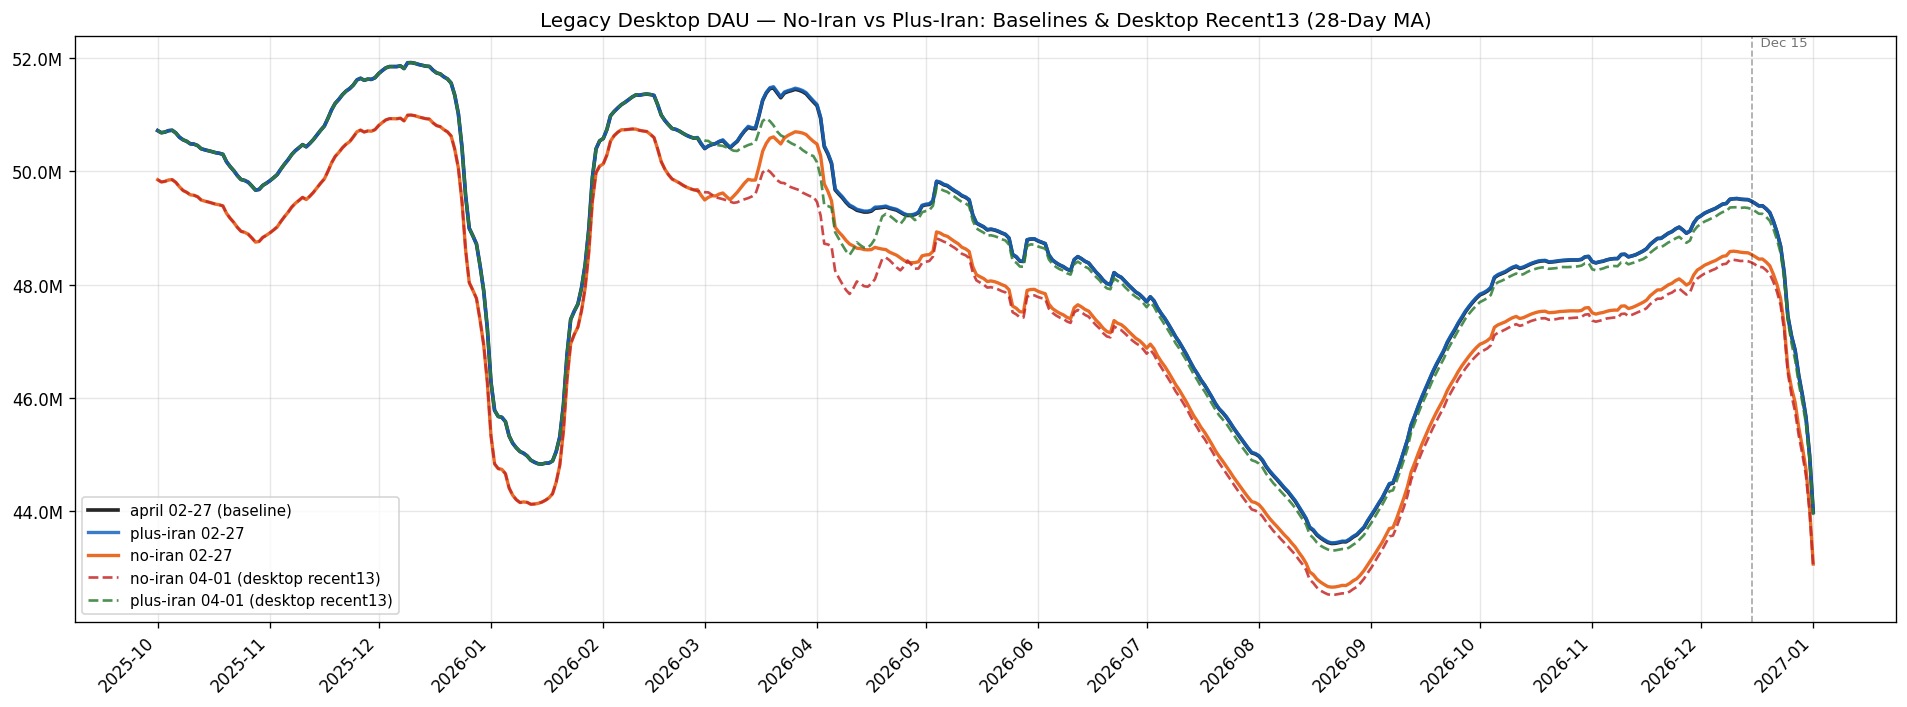

In [4]:
# [plot-all-variants]
fig, ax = plt.subplots(figsize=(16, 6))

for key in FORECAST_FILES:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(desktop_data[key])
    df_plot = trim(df_ma)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — No-Iran vs Plus-Iran: Baselines & Desktop Recent13 (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower left', fontsize=9)
mark_accounting_date(ax)
apply_date_axis(ax)

plt.tight_layout()
plt.show()


## No-Iran

Compare no-iran forecasts (which exclude Iran entirely) against actuals **excluding** Iran.


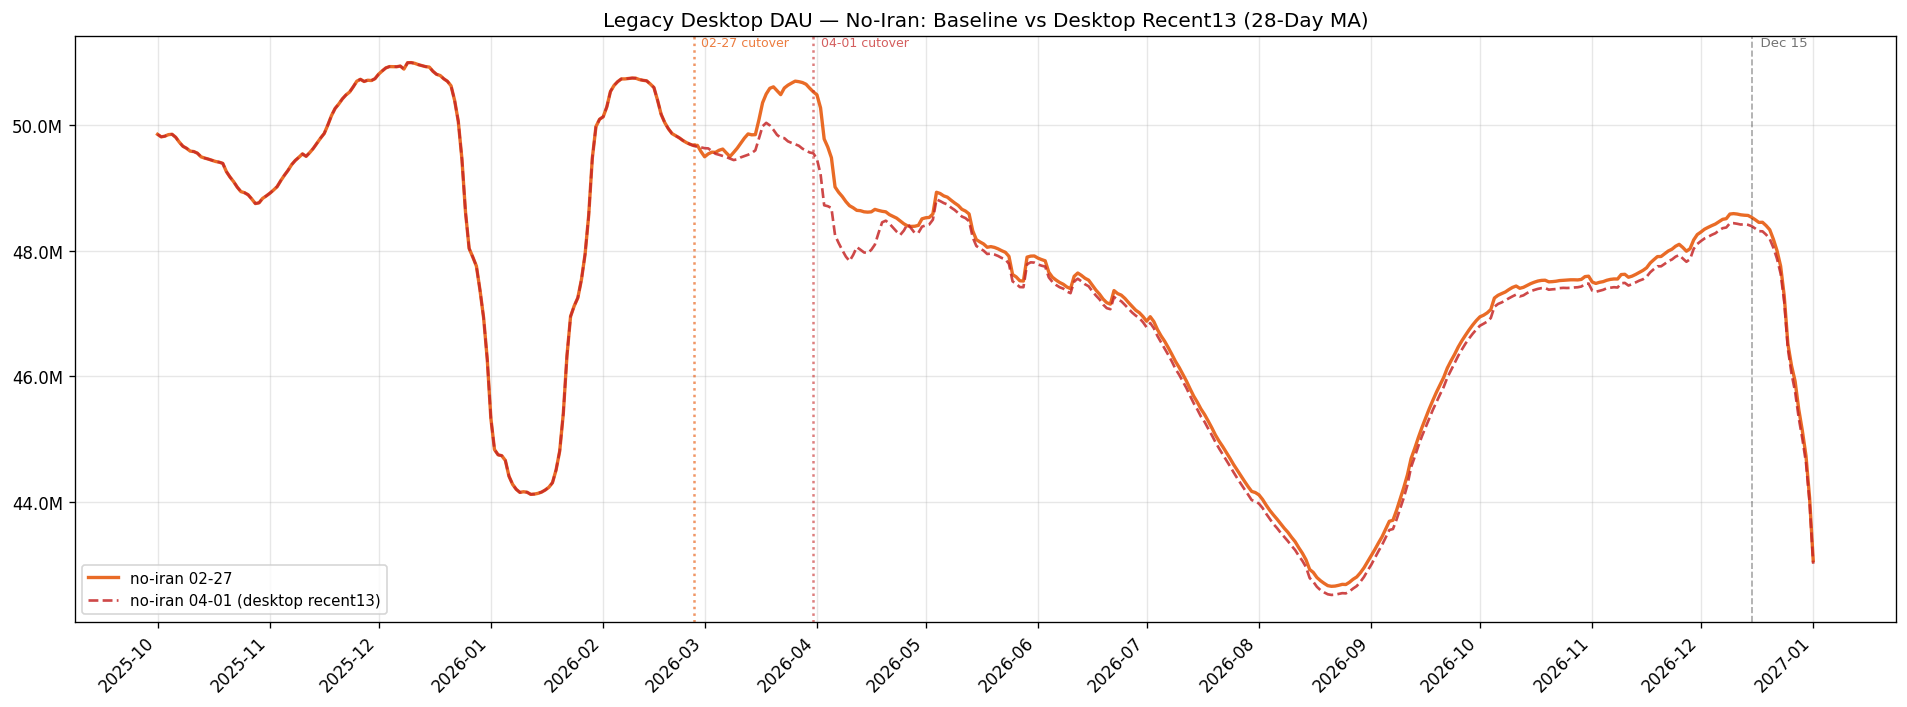

In [5]:
# [no-iran-plot-baseline]
NI_KEYS = ['no-iran 02-27', 'no-iran 04-01 (desktop recent13)']

fig, ax = plt.subplots(figsize=(16, 6))

for key in NI_KEYS:
    style = DATASET_STYLES[key]
    df_full = desktop_data[key].copy()
    df_ma = add_ma28(df_full)
    df_plot = trim(df_ma)

    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

    boundary = df_full.loc[
        df_full['data_type'].isin(['training', 'actual']),
        'target_date'
    ].max()
    if pd.notna(boundary):
        ax.axvline(boundary, color=style['color'], linestyle=':',
                   linewidth=1.5, alpha=0.6)
        ymin, ymax = ax.get_ylim()
        ax.text(boundary + pd.Timedelta(days=2), ymax,
                f'{key.split()[1][:5]} cutover',
                va='top', ha='left', fontsize=7.5, color=style['color'], alpha=0.75)

ax.set_title('Legacy Desktop DAU — No-Iran: Baseline vs Desktop Recent13 (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower left', fontsize=9)
mark_accounting_date(ax)
apply_date_axis(ax)

plt.tight_layout()
plt.show()


In [6]:
# [no-iran-ma28-on-apr05]
SNAPSHOT_DATE = pd.Timestamp('2026-04-05')

print(f'No-Iran — 28-day MA on {SNAPSHOT_DATE.date()}:')
print()
for key in NI_KEYS:
    df_ma = add_ma28(desktop_data[key])
    row = df_ma.loc[df_ma['target_date'] == SNAPSHOT_DATE]
    if len(row) == 0:
        print(f'  {key:40s}:  no data for this date')
    else:
        val = row['dau_ma28'].values[0]
        print(f'  {key:40s}:  {val:>14,.0f}')


No-Iran — 28-day MA on 2026-04-05:

  no-iran 02-27                           :      49,476,024
  no-iran 04-01 (desktop recent13)        :      48,677,517


In [7]:
# [no-iran-summary-stats]
baseline_key = 'no-iran 02-27'
variant_key = 'no-iran 04-01 (desktop recent13)'
baseline_ma = add_ma28(desktop_data[baseline_key])
variant_ma = add_ma28(desktop_data[variant_key])

merged = baseline_ma[['target_date', 'dau_ma28']].merge(
    variant_ma[['target_date', 'dau_ma28']],
    on='target_date', suffixes=('_baseline', '_variant')
).dropna()
merged = merged[
    (merged['target_date'] >= PLOT_START)
    & (merged['target_date'] <= PLOT_END)
]

diff = merged['dau_ma28_variant'] - merged['dau_ma28_baseline']
pct_diff = 100 * diff / merged['dau_ma28_baseline']

dec15 = merged.loc[merged['target_date'] == ACCOUNTING_DATE]
dec15_baseline = dec15['dau_ma28_baseline'].values[0] if len(dec15) else np.nan
dec15_variant = dec15['dau_ma28_variant'].values[0] if len(dec15) else np.nan
dec15_diff = dec15_variant - dec15_baseline if not np.isnan(dec15_baseline) else np.nan
dec15_pct = 100 * dec15_diff / dec15_baseline if not np.isnan(dec15_baseline) else np.nan

print('=== No-Iran: desktop recent13 vs baseline (28-day MA, plot window) ===')
print(f'  Mean diff:      {diff.mean():>12,.0f}  ({pct_diff.mean():+.2f}%)')
print(f'  Max |diff|:     {diff.abs().max():>12,.0f}  ({pct_diff.abs().max():.2f}%)')
print(f'  Dec 15 MA28:    {dec15_variant:>12,.0f}  vs baseline {dec15_baseline:,.0f}  ({dec15_pct:+.2f}%)')


=== No-Iran: desktop recent13 vs baseline (28-day MA, plot window) ===
  Mean diff:          -132,119  (-0.28%)
  Max |diff|:        1,054,893  (2.12%)
  Dec 15 MA28:      48,389,006  vs baseline 48,528,407  (-0.29%)


In [36]:
# [query-actuals-no-iran]
# Query BQ for actual world-level desktop DAU (excluding Iran).
import time
from pathlib import Path
from google.cloud import bigquery

PROJECT = "moz-fx-data-bq-data-science"
CHECKPOINT_DIR = Path("data")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ACTUALS_END = "2026-04-12"

QUERY_DESKTOP_ACTUALS_NO_IRAN = f"""
SELECT
    submission_date AS date,
    SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE app_name = "Firefox Desktop"
  AND submission_date BETWEEN '2020-01-01' AND '{ACTUALS_END}'
  AND country != 'IR'
GROUP BY submission_date
ORDER BY 1
"""

checkpoint_no_iran = CHECKPOINT_DIR / "compare_desktop_actuals_no_iran.parquet"
if checkpoint_no_iran.exists():
    print(f"Loading checkpoint: {checkpoint_no_iran}")
    df_actuals_no_iran = pd.read_parquet(checkpoint_no_iran)
    print(f"Loaded | Rows: {len(df_actuals_no_iran):,} | {df_actuals_no_iran['date'].min()} to {df_actuals_no_iran['date'].max()}")
else:
    print("Querying BigQuery (desktop actuals, no Iran)...")
    t0 = time.time()
    df_actuals_no_iran = bigquery.Client(PROJECT).query(QUERY_DESKTOP_ACTUALS_NO_IRAN).to_dataframe()
    elapsed = time.time() - t0
    print(f"Query complete | {elapsed:.1f}s | Rows: {len(df_actuals_no_iran):,}")
    df_actuals_no_iran.to_parquet(checkpoint_no_iran)
    print(f"Saved to {checkpoint_no_iran}")

df_actuals_no_iran['date'] = pd.to_datetime(df_actuals_no_iran['date'])
df_actuals_no_iran = df_actuals_no_iran.sort_values('date').reset_index(drop=True)
df_actuals_no_iran['dau_ma28'] = df_actuals_no_iran['dau'].rolling(28, min_periods=28).mean()

print(f"\nDate range: {df_actuals_no_iran['date'].min().date()} to {df_actuals_no_iran['date'].max().date()}")
print(f"Last 5 days MA28:")
print(df_actuals_no_iran[['date', 'dau', 'dau_ma28']].tail(5).to_string(index=False))


Querying BigQuery (desktop actuals, no Iran)...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Query complete | 68.8s | Rows: 2,293
Saved to data/compare_desktop_actuals_no_iran.parquet

Date range: 2020-01-01 to 2026-04-11
Last 5 days MA28:
      date      dau     dau_ma28
2026-04-07 55208105 4.823567e+07
2026-04-08 55537143 4.817478e+07
2026-04-09 54972507 4.811718e+07
2026-04-10 53166789 4.809195e+07
2026-04-11 36384167 4.804463e+07


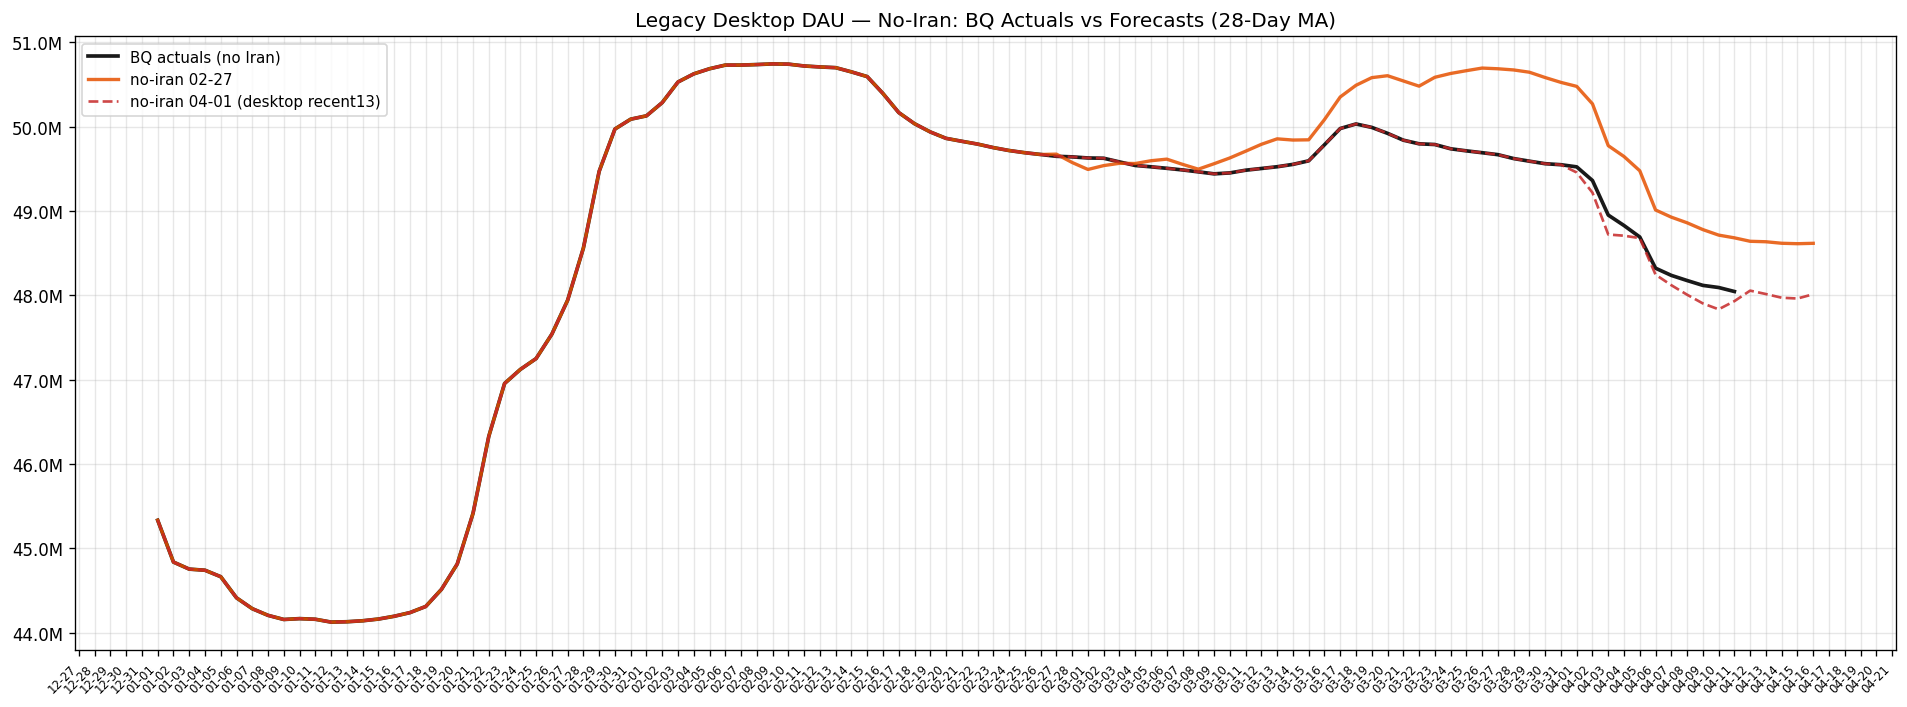

In [50]:
# [no-iran-plot-actuals-long]
NI_ZOOM_START = pd.Timestamp('2026-01-01')
NI_ZOOM_END = pd.Timestamp('2026-04-16')

fig, ax = plt.subplots(figsize=(16, 6))

actuals_plot = df_actuals_no_iran[
    (df_actuals_no_iran['date'] >= NI_ZOOM_START)
    & (df_actuals_no_iran['date'] <= NI_ZOOM_END)
]
ax.plot(actuals_plot['date'], actuals_plot['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (no Iran)')

for key in NI_KEYS:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(desktop_data[key])
    df_plot = trim(df_ma, start=NI_ZOOM_START, end=NI_ZOOM_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — No-Iran: BQ Actuals vs Forecasts (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


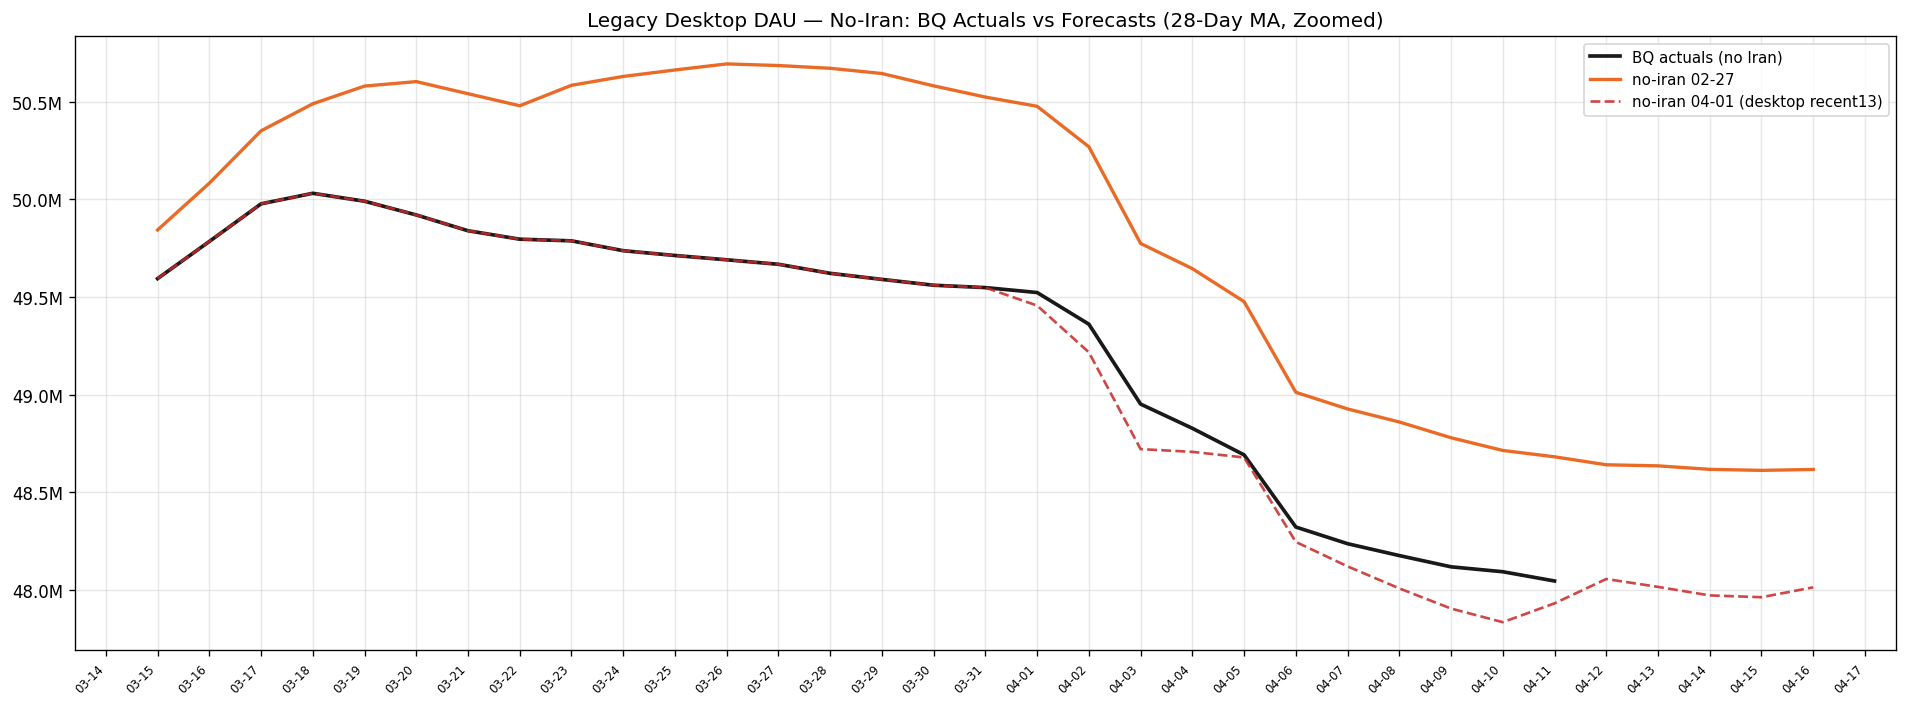

In [51]:
# [no-iran-plot-actuals-zoom]
NI_CLOSE_START = pd.Timestamp('2026-03-15')
NI_CLOSE_END = pd.Timestamp('2026-04-16')

fig, ax = plt.subplots(figsize=(16, 6))

actuals_zoom = df_actuals_no_iran[
    (df_actuals_no_iran['date'] >= NI_CLOSE_START)
    & (df_actuals_no_iran['date'] <= NI_CLOSE_END)
]
ax.plot(actuals_zoom['date'], actuals_zoom['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (no Iran)')

for key in NI_KEYS:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(desktop_data[key])
    df_plot = trim(df_ma, start=NI_CLOSE_START, end=NI_CLOSE_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — No-Iran: BQ Actuals vs Forecasts (28-Day MA, Zoomed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


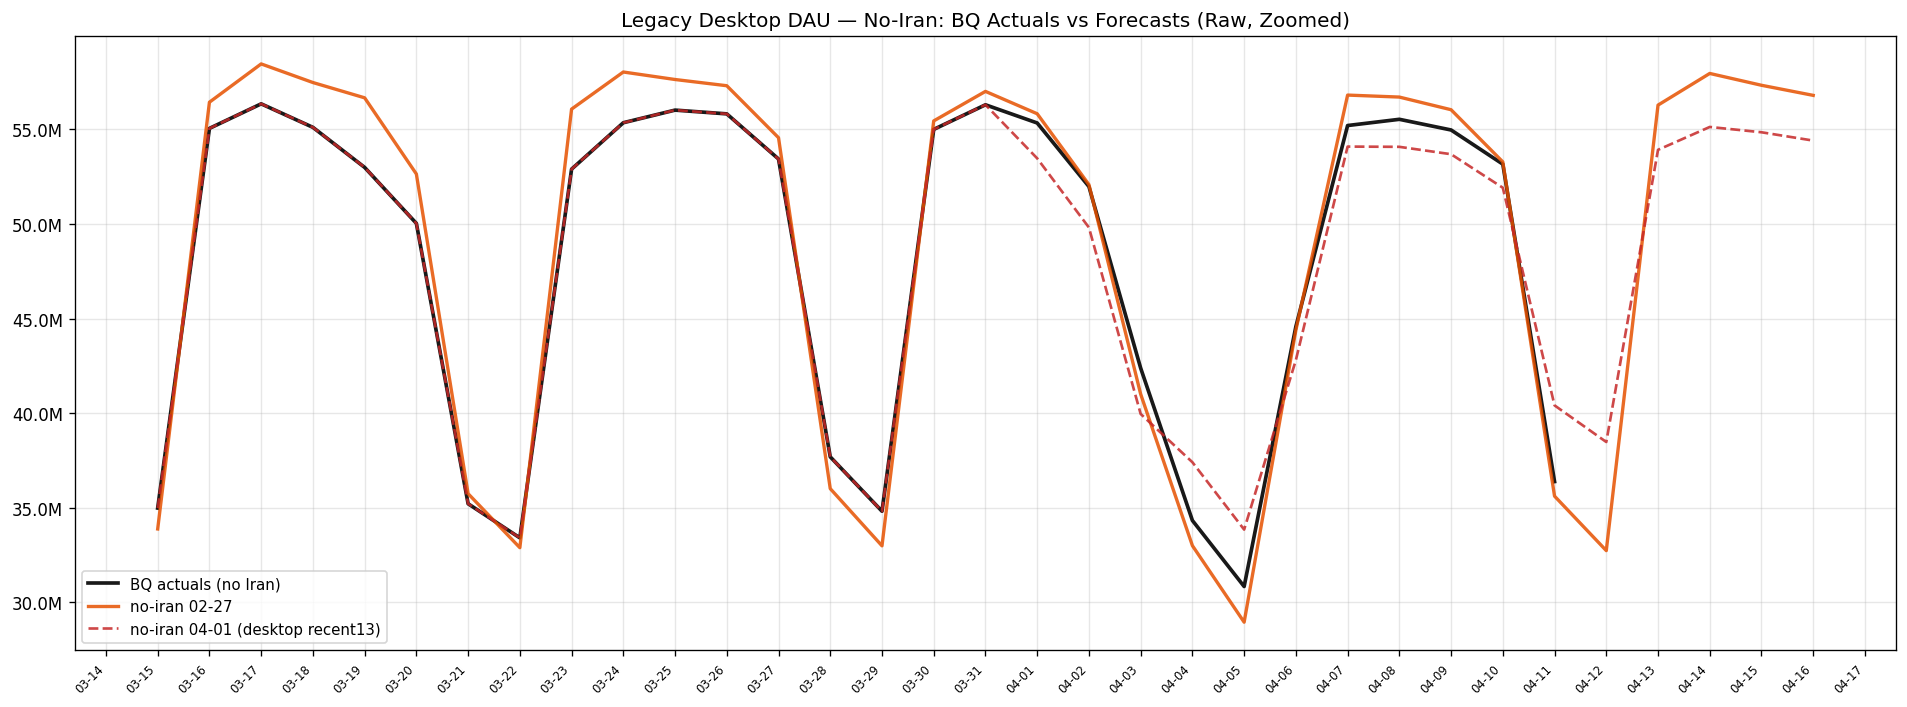

In [52]:
# [no-iran-plot-actuals-raw]
fig, ax = plt.subplots(figsize=(16, 6))

actuals_raw = df_actuals_no_iran[
    (df_actuals_no_iran['date'] >= NI_CLOSE_START)
    & (df_actuals_no_iran['date'] <= NI_CLOSE_END)
]
ax.plot(actuals_raw['date'], actuals_raw['dau'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (no Iran)')

for key in NI_KEYS:
    style = DATASET_STYLES[key]
    df_plot = trim(desktop_data[key], start=NI_CLOSE_START, end=NI_CLOSE_END)
    ax.plot(df_plot['target_date'], df_plot['dau'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — No-Iran: BQ Actuals vs Forecasts (Raw, Zoomed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


In [40]:
# [no-iran-ma28-dec15]
baseline_key = 'no-iran 02-27'
variant_key = 'no-iran 04-01 (desktop recent13)'

baseline_ma = add_ma28(desktop_data[baseline_key])
baseline_row = baseline_ma.loc[baseline_ma['target_date'] == ACCOUNTING_DATE]
baseline_val = baseline_row['dau_ma28'].values[0] if len(baseline_row) else np.nan

variant_ma = add_ma28(desktop_data[variant_key])
variant_row = variant_ma.loc[variant_ma['target_date'] == ACCOUNTING_DATE]
variant_val = variant_row['dau_ma28'].values[0] if len(variant_row) else np.nan

diff = variant_val - baseline_val
pct = 100 * diff / baseline_val if not np.isnan(baseline_val) else np.nan

print(f'No-Iran — 28-day MA on {ACCOUNTING_DATE.date()}:')
print()
header = f"  {'Variant':<45s}  {'MA28':>14s}  {'Diff vs baseline':>16s}  {'Pct':>8s}"
print(header)
print(f"  {'-'*45}  {'-'*14}  {'-'*16}  {'-'*8}")
print(f"  {baseline_key:<45s}  {baseline_val:>14,.0f}  {'—':>16s}  {'—':>8s}")
print(f"  {variant_key:<45s}  {variant_val:>14,.0f}  {diff:>+16,.0f}  {pct:>+7.2f}%")


No-Iran — 28-day MA on 2026-12-15:

  Variant                                                  MA28  Diff vs baseline       Pct
  ---------------------------------------------  --------------  ----------------  --------
  no-iran 02-27                                      48,528,407                 —         —
  no-iran 04-01 (desktop recent13)                   48,389,006          -139,401    -0.29%


## Plus-Iran

Compare plus-Iran forecasts (no-Iran forecast + synthetic Iran values) against actuals **including** Iran.


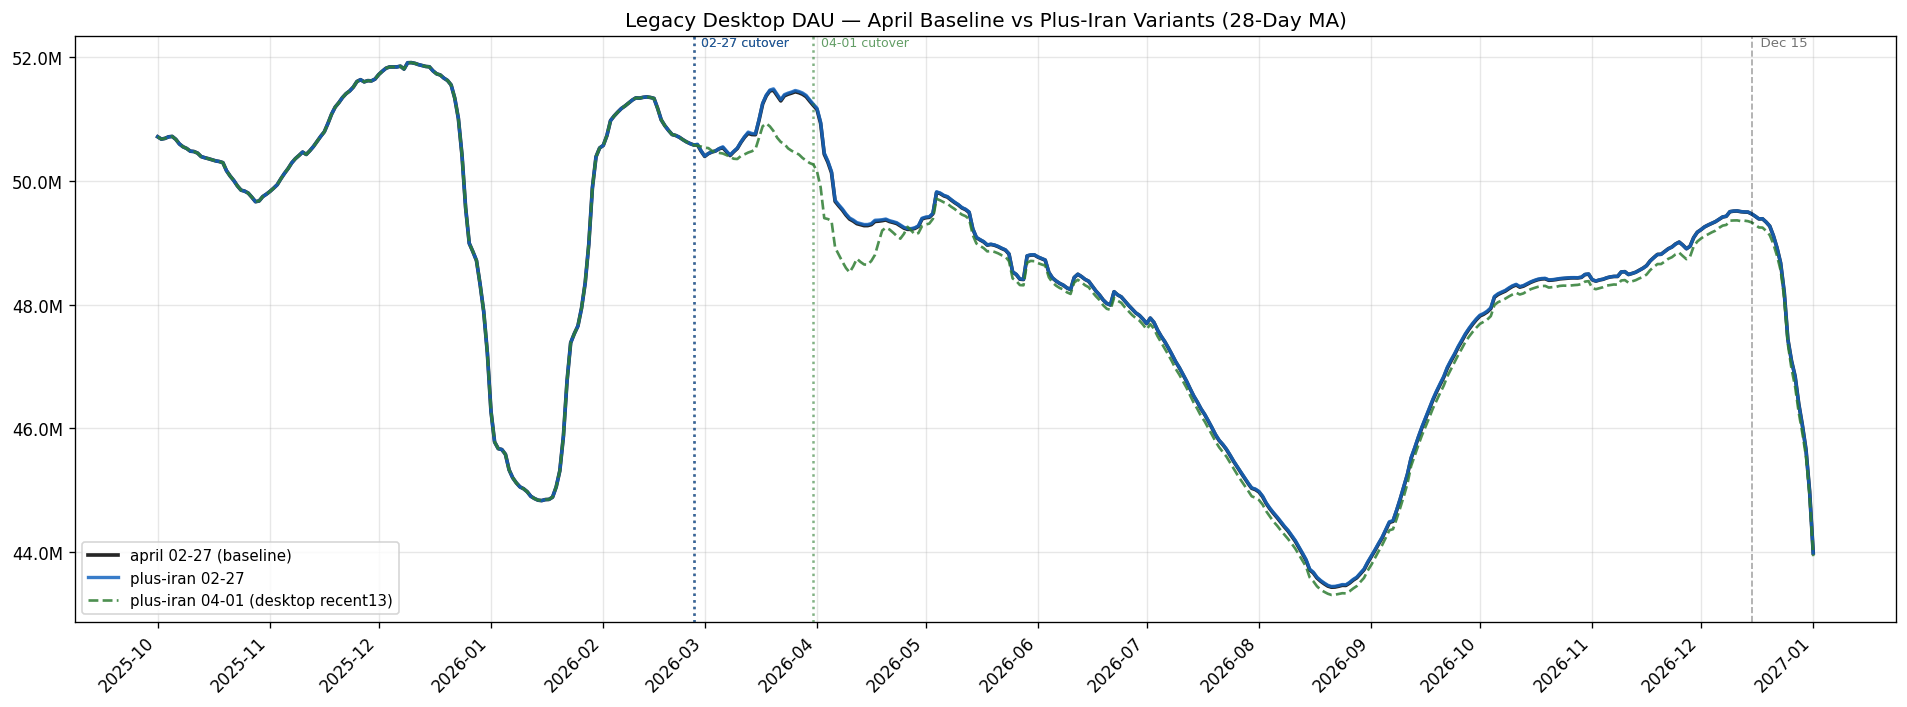

In [41]:
# [plus-iran-plot-baseline]
PI_KEYS = ['april 02-27 (baseline)', 'plus-iran 02-27', 'plus-iran 04-01 (desktop recent13)']

fig, ax = plt.subplots(figsize=(16, 6))

for key in PI_KEYS:
    style = DATASET_STYLES[key]
    df_full = desktop_data[key].copy()
    df_ma = add_ma28(df_full)
    df_plot = trim(df_ma)

    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

    boundary = df_full.loc[
        df_full['data_type'].isin(['training', 'actual']),
        'target_date'
    ].max()
    if pd.notna(boundary):
        ax.axvline(boundary, color=style['color'], linestyle=':',
                   linewidth=1.5, alpha=0.6)
        ymin, ymax = ax.get_ylim()
        ax.text(boundary + pd.Timedelta(days=2), ymax,
                f'{key.split()[1][:5]} cutover',
                va='top', ha='left', fontsize=7.5, color=style['color'], alpha=0.75)

ax.set_title('Legacy Desktop DAU — April Baseline vs Plus-Iran Variants (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower left', fontsize=9)
mark_accounting_date(ax)
apply_date_axis(ax)

plt.tight_layout()
plt.show()


In [42]:
# [plus-iran-ma28-on-apr05]
SNAPSHOT_DATE = pd.Timestamp('2026-04-05')

print(f'Plus-Iran — 28-day MA on {SNAPSHOT_DATE.date()}:')
print()
for key in PI_KEYS:
    df_ma = add_ma28(desktop_data[key])
    row = df_ma.loc[df_ma['target_date'] == SNAPSHOT_DATE]
    if len(row) == 0:
        print(f'  {key:45s}:  no data for this date')
    else:
        val = row['dau_ma28'].values[0]
        print(f'  {key:45s}:  {val:>14,.0f}')


Plus-Iran — 28-day MA on 2026-04-05:

  april 02-27 (baseline)                       :      50,134,417
  plus-iran 02-27                              :      50,153,852
  plus-iran 04-01 (desktop recent13)           :      49,355,345


In [43]:
# [plus-iran-ma28-on-dec15]
SNAPSHOT_DATE = pd.Timestamp('2026-12-15')

print(f'Plus-Iran — 28-day MA on {SNAPSHOT_DATE.date()}:')
print()
for key in PI_KEYS:
    df_ma = add_ma28(desktop_data[key])
    row = df_ma.loc[df_ma['target_date'] == SNAPSHOT_DATE]
    if len(row) == 0:
        print(f'  {key:45s}:  no data for this date')
    else:
        val = row['dau_ma28'].values[0]
        print(f'  {key:45s}:  {val:>14,.0f}')


Plus-Iran — 28-day MA on 2026-12-15:

  april 02-27 (baseline)                       :      49,467,237
  plus-iran 02-27                              :      49,469,657
  plus-iran 04-01 (desktop recent13)           :      49,330,256


In [44]:
# [plus-iran-summary-stats]
baseline_key = 'april 02-27 (baseline)'
variant_key = 'plus-iran 04-01 (desktop recent13)'
baseline_ma = add_ma28(desktop_data[baseline_key])
variant_ma = add_ma28(desktop_data[variant_key])

merged = baseline_ma[['target_date', 'dau_ma28']].merge(
    variant_ma[['target_date', 'dau_ma28']],
    on='target_date', suffixes=('_baseline', '_variant')
).dropna()
merged = merged[
    (merged['target_date'] >= PLOT_START)
    & (merged['target_date'] <= PLOT_END)
]

diff = merged['dau_ma28_variant'] - merged['dau_ma28_baseline']
pct_diff = 100 * diff / merged['dau_ma28_baseline']

dec15 = merged.loc[merged['target_date'] == ACCOUNTING_DATE]
dec15_baseline = dec15['dau_ma28_baseline'].values[0] if len(dec15) else np.nan
dec15_variant = dec15['dau_ma28_variant'].values[0] if len(dec15) else np.nan
dec15_diff = dec15_variant - dec15_baseline if not np.isnan(dec15_baseline) else np.nan
dec15_pct = 100 * dec15_diff / dec15_baseline if not np.isnan(dec15_baseline) else np.nan

print('=== Plus-Iran: desktop recent13 vs april baseline (28-day MA, plot window) ===')
print(f'  Mean diff:      {diff.mean():>12,.0f}  ({pct_diff.mean():+.2f}%)')
print(f'  Max |diff|:     {diff.abs().max():>12,.0f}  ({pct_diff.abs().max():.2f}%)')
print(f'  Dec 15 MA28:    {dec15_variant:>12,.0f}  vs baseline {dec15_baseline:,.0f}  ({dec15_pct:+.2f}%)')


=== Plus-Iran: desktop recent13 vs april baseline (28-day MA, plot window) ===
  Mean diff:          -126,735  (-0.26%)
  Max |diff|:        1,033,855  (2.05%)
  Dec 15 MA28:      49,330,256  vs baseline 49,467,237  (-0.28%)


In [45]:
# [query-actuals-with-iran]
# Query BQ for actual world-level desktop DAU (INCLUDING Iran).

QUERY_DESKTOP_ACTUALS_WITH_IRAN = f"""
SELECT
    submission_date AS date,
    SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE app_name = "Firefox Desktop"
  AND submission_date BETWEEN '2020-01-01' AND '{ACTUALS_END}'
GROUP BY submission_date
ORDER BY 1
"""

checkpoint_with_iran = CHECKPOINT_DIR / "compare_desktop_actuals_with_iran.parquet"
if checkpoint_with_iran.exists():
    print(f"Loading checkpoint: {checkpoint_with_iran}")
    df_actuals_with_iran = pd.read_parquet(checkpoint_with_iran)
    print(f"Loaded | Rows: {len(df_actuals_with_iran):,} | {df_actuals_with_iran['date'].min()} to {df_actuals_with_iran['date'].max()}")
else:
    print("Querying BigQuery (desktop actuals, with Iran)...")
    t0 = time.time()
    df_actuals_with_iran = bigquery.Client(PROJECT).query(QUERY_DESKTOP_ACTUALS_WITH_IRAN).to_dataframe()
    elapsed = time.time() - t0
    print(f"Query complete | {elapsed:.1f}s | Rows: {len(df_actuals_with_iran):,}")
    df_actuals_with_iran.to_parquet(checkpoint_with_iran)
    print(f"Saved to {checkpoint_with_iran}")

df_actuals_with_iran['date'] = pd.to_datetime(df_actuals_with_iran['date'])
df_actuals_with_iran = df_actuals_with_iran.sort_values('date').reset_index(drop=True)
df_actuals_with_iran['dau_ma28'] = df_actuals_with_iran['dau'].rolling(28, min_periods=28).mean()

print(f"\nDate range: {df_actuals_with_iran['date'].min().date()} to {df_actuals_with_iran['date'].max().date()}")
print(f"Last 5 days MA28:")
print(df_actuals_with_iran[['date', 'dau', 'dau_ma28']].tail(5).to_string(index=False))


Loading checkpoint: data/compare_desktop_actuals_with_iran.parquet
Loaded | Rows: 2,288 | 2020-01-01 to 2026-04-06

Date range: 2020-01-01 to 2026-04-06
Last 5 days MA28:
      date      dau     dau_ma28
2026-04-02 51985415 4.936775e+07
2026-04-03 42388970 4.895831e+07
2026-04-04 34338572 4.883453e+07
2026-04-05 30850974 4.869851e+07
2026-04-06 44591626 4.832908e+07


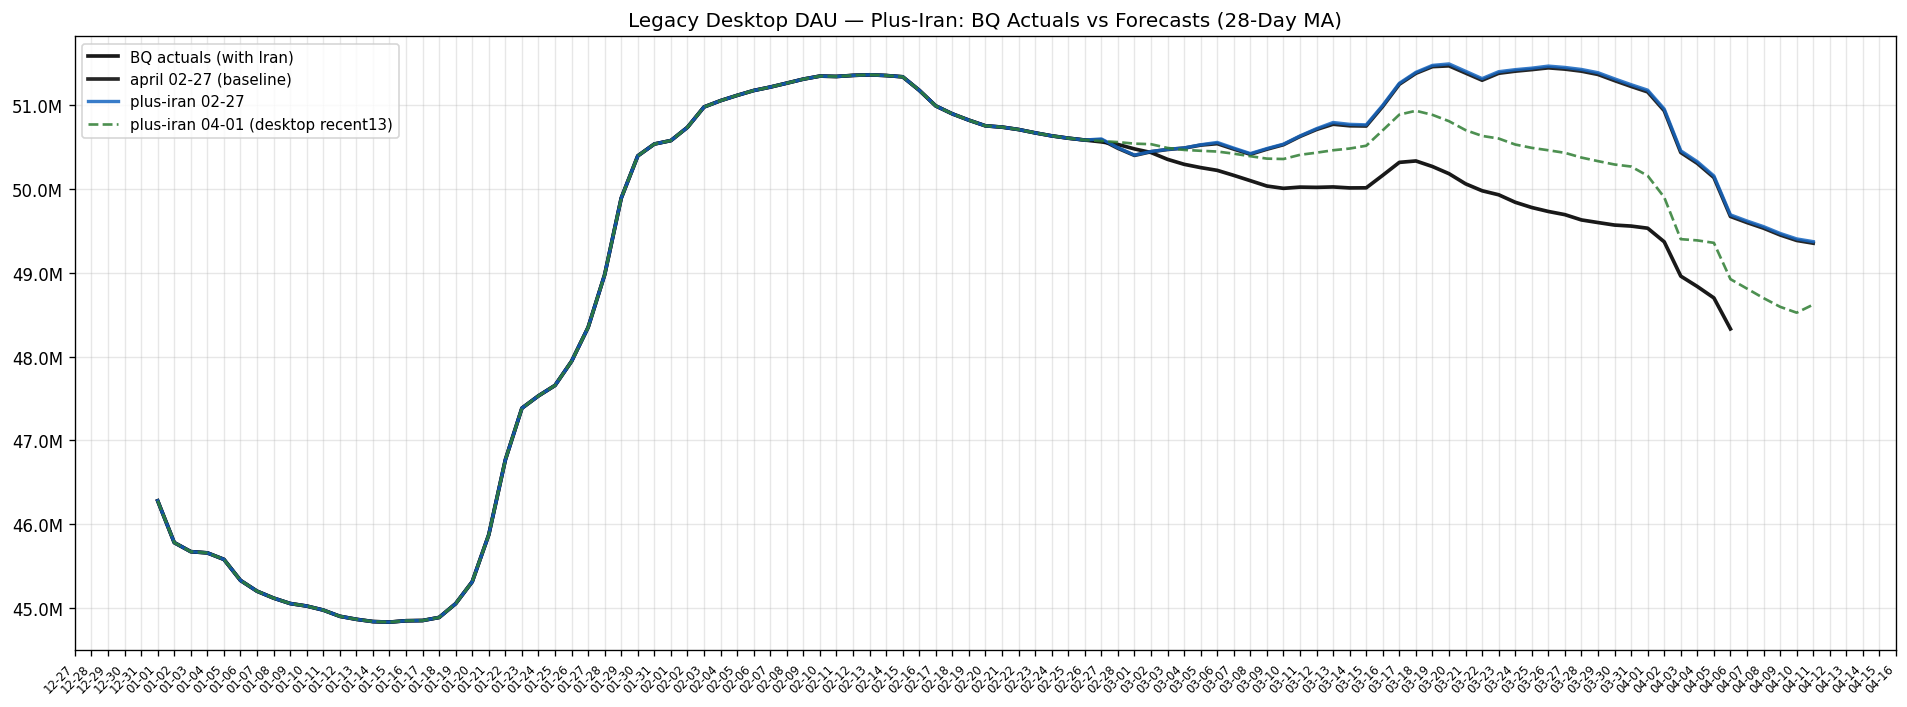

In [46]:
# [plus-iran-plot-actuals-long]
FI_ZOOM_START = pd.Timestamp('2026-01-01')
FI_ZOOM_END = pd.Timestamp('2026-04-11')

fig, ax = plt.subplots(figsize=(16, 6))

actuals_plot = df_actuals_with_iran[
    (df_actuals_with_iran['date'] >= FI_ZOOM_START)
    & (df_actuals_with_iran['date'] <= FI_ZOOM_END)
]
ax.plot(actuals_plot['date'], actuals_plot['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (with Iran)')

for key in PI_KEYS:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(desktop_data[key])
    df_plot = trim(df_ma, start=FI_ZOOM_START, end=FI_ZOOM_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — Plus-Iran: BQ Actuals vs Forecasts (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


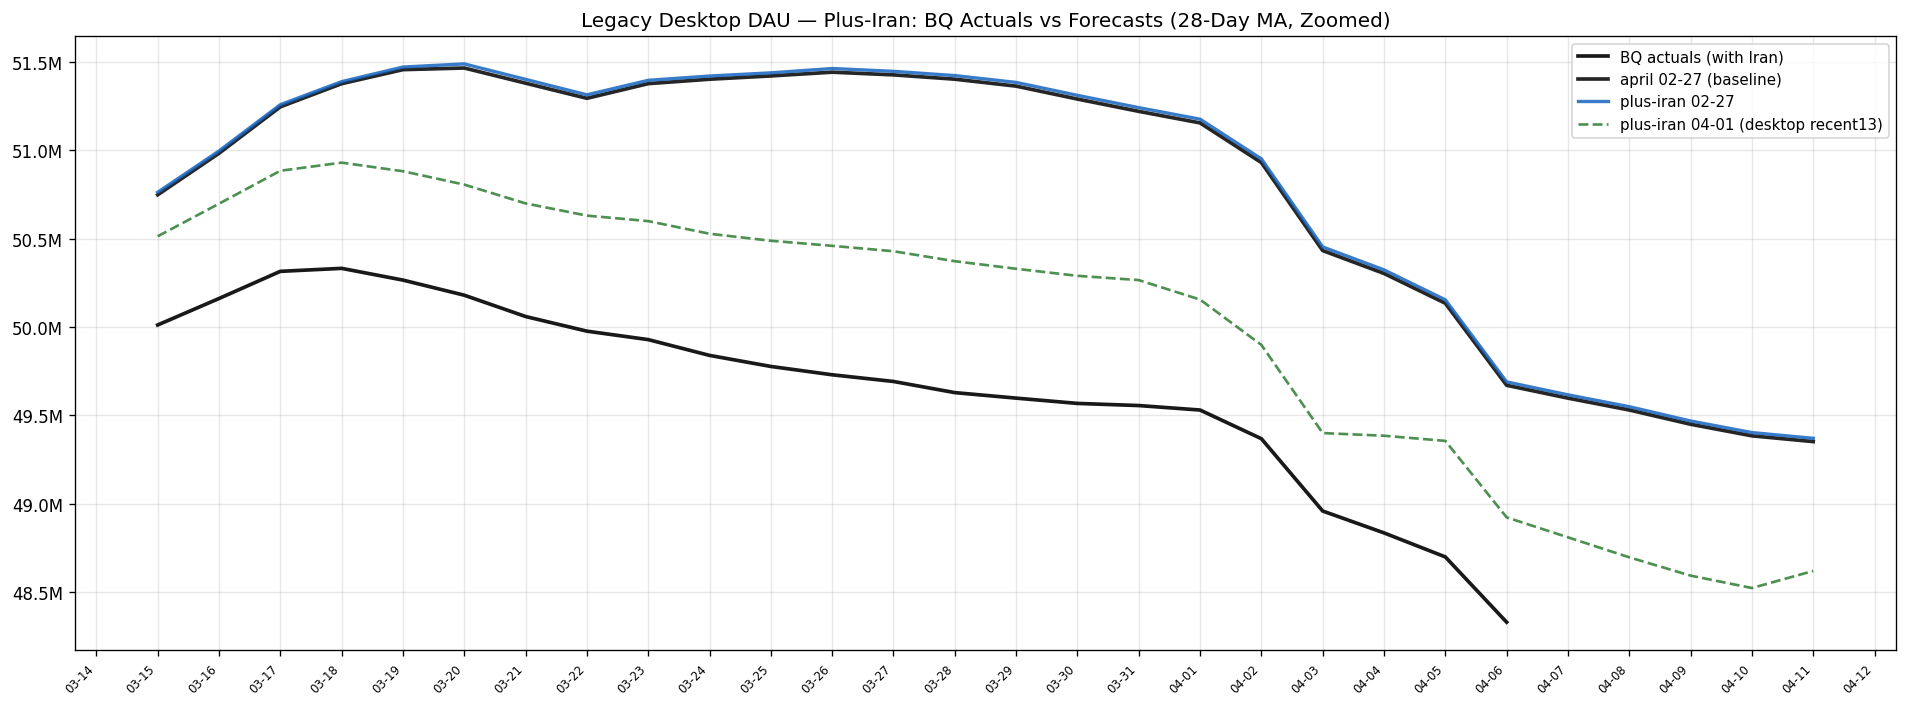

In [47]:
# [plus-iran-plot-actuals-zoom]
FI_CLOSE_START = pd.Timestamp('2026-03-15')
FI_CLOSE_END = pd.Timestamp('2026-04-11')

fig, ax = plt.subplots(figsize=(16, 6))

actuals_zoom = df_actuals_with_iran[
    (df_actuals_with_iran['date'] >= FI_CLOSE_START)
    & (df_actuals_with_iran['date'] <= FI_CLOSE_END)
]
ax.plot(actuals_zoom['date'], actuals_zoom['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (with Iran)')

for key in PI_KEYS:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(desktop_data[key])
    df_plot = trim(df_ma, start=FI_CLOSE_START, end=FI_CLOSE_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — Plus-Iran: BQ Actuals vs Forecasts (28-Day MA, Zoomed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


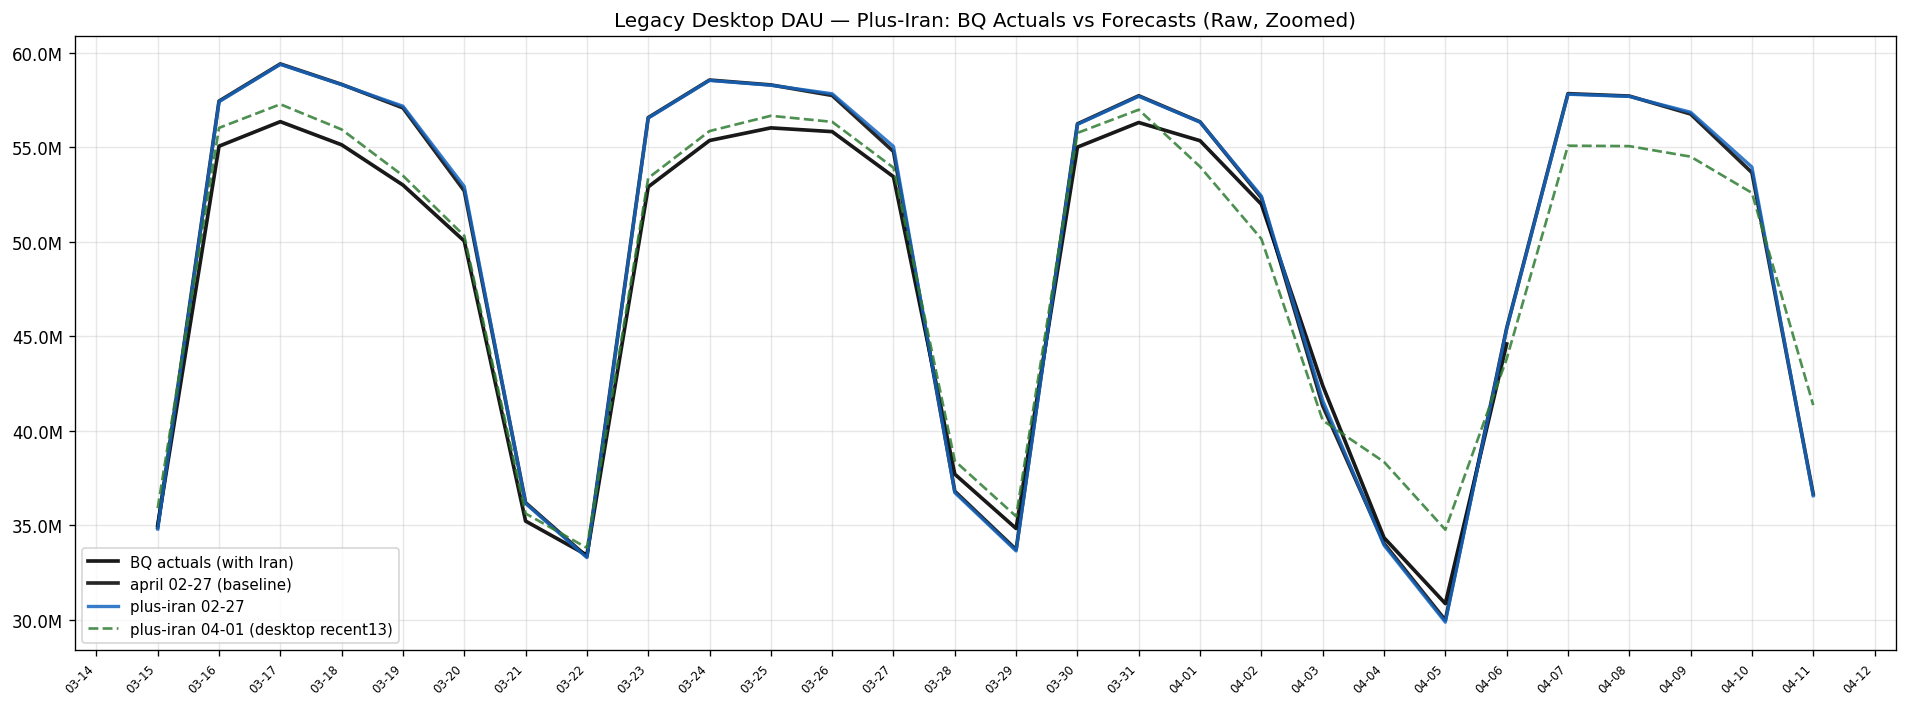

In [48]:
# [plus-iran-plot-actuals-raw]
fig, ax = plt.subplots(figsize=(16, 6))

actuals_raw = df_actuals_with_iran[
    (df_actuals_with_iran['date'] >= FI_CLOSE_START)
    & (df_actuals_with_iran['date'] <= FI_CLOSE_END)
]
ax.plot(actuals_raw['date'], actuals_raw['dau'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (with Iran)')

for key in PI_KEYS:
    style = DATASET_STYLES[key]
    df_plot = trim(desktop_data[key], start=FI_CLOSE_START, end=FI_CLOSE_END)
    ax.plot(df_plot['target_date'], df_plot['dau'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Legacy Desktop DAU — Plus-Iran: BQ Actuals vs Forecasts (Raw, Zoomed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


In [49]:
# [plus-iran-ma28-dec15]
baseline_key = 'april 02-27 (baseline)'
variant_key = 'plus-iran 04-01 (desktop recent13)'

baseline_ma = add_ma28(desktop_data[baseline_key])
baseline_row = baseline_ma.loc[baseline_ma['target_date'] == ACCOUNTING_DATE]
baseline_val = baseline_row['dau_ma28'].values[0] if len(baseline_row) else np.nan

variant_ma = add_ma28(desktop_data[variant_key])
variant_row = variant_ma.loc[variant_ma['target_date'] == ACCOUNTING_DATE]
variant_val = variant_row['dau_ma28'].values[0] if len(variant_row) else np.nan

diff = variant_val - baseline_val
pct = 100 * diff / baseline_val if not np.isnan(baseline_val) else np.nan

print(f'Plus-Iran — 28-day MA on {ACCOUNTING_DATE.date()}:')
print()
header = f"  {'Variant':<45s}  {'MA28':>14s}  {'Diff vs baseline':>16s}  {'Pct':>8s}"
print(header)
print(f"  {'-'*45}  {'-'*14}  {'-'*16}  {'-'*8}")
print(f"  {baseline_key:<45s}  {baseline_val:>14,.0f}  {'—':>16s}  {'—':>8s}")
print(f"  {variant_key:<45s}  {variant_val:>14,.0f}  {diff:>+16,.0f}  {pct:>+7.2f}%")


Plus-Iran — 28-day MA on 2026-12-15:

  Variant                                                  MA28  Diff vs baseline       Pct
  ---------------------------------------------  --------------  ----------------  --------
  april 02-27 (baseline)                             49,467,237                 —         —
  plus-iran 04-01 (desktop recent13)                 49,330,256          -136,980    -0.28%
